In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import tensorflow as tf

import math
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns
import os
import cv2
import random
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical

In [5]:
train_dir ="/content/drive/MyDrive/Rock_paper dataset/archive.zip (Unzipped Files)/Rock-Paper-Scissors/train"
test_dir ="/content/drive/MyDrive/Rock_paper dataset/archive.zip (Unzipped Files)/Rock-Paper-Scissors/test"

visualizig image augumentation

In [6]:

sample_generator = ImageDataGenerator(
    rescale=1./255, # so that all the images would between 0 and 1
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=90,
    height_shift_range=0.2,
    width_shift_range=0.2
)

sample_images = sample_generator.flow_from_directory(
    train_dir,
    target_size=(300, 300),#rezining to 300x300,
    color_mode='rgb',
    class_mode=None,
    batch_size=1,#1 imaage at a time
    shuffle=True,
    seed=42 #reproduce the suffle
)

Found 2523 images belonging to 3 classes.


AttributeError: 'DirectoryIterator' object has no attribute 'next'

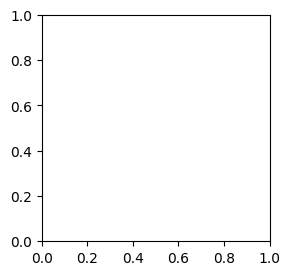

In [7]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = sample_images.next()[0]
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [ ]:
train_generator = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=90,
    height_shift_range=0.2,
    width_shift_range=0.2,
    zoom_range=0.2
)

test_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.7
)

In [ ]:
train_images = train_generator.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

val_images = test_generator.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)


test_images = test_generator.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42,
    subset='validation'
)

In [ ]:

# Function to load images from directory
def load_images_from_directory(directory, target_size=(150, 150)):
    images = []
    labels = []
    label_map = {}
    label_idx = 0
    for class_name in os.listdir(directory):
        label_map[label_idx] = class_name
        class_dir = os.path.join(directory, class_name)
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
            image = cv2.resize(image, target_size)
            images.append(image)
            labels.append(label_idx)
        label_idx += 1
    return np.array(images), np.array(labels), label_map

# training dataset t
train_dir = "/content/drive/MyDrive/Rock_paper dataset/archive.zip (Unzipped Files)/Rock-Paper-Scissors/train"
train_images, train_labels, label_map = load_images_from_directory(train_dir)

train_images = train_images / 255.0

#  testing dataset
test_dir = "/content/drive/MyDrive/Rock_paper dataset/archive.zip (Unzipped Files)/Rock-Paper-Scissors/test"
test_images, test_labels, _ = load_images_from_directory(test_dir)

test_images = test_images / 255.0


# Convert labels to one-hot encoding
num_classes = len(label_map)
train_labels = to_categorical(train_labels, num_classes)
test_labels = to_categorical(test_labels, num_classes)


model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.4),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_data=(test_images, test_labels))




In [ ]:
# acc = model.evaluate(test_images, verbose=0)[1]
# print("Accuracy: {:.2f}%".format(acc * 100))

# predictions = np.argmax(model.predict(test_images), axis=1)

# cm = confusion_matrix(test_images.labels, predictions, labels=[0, 1, 2])
# clr = classification_report(test_images.labels, predictions, labels=[0, 1, 2], target_names=["Paper", "Rock", "Scissors"])

# plt.figure(figsize=(8, 8))
# sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False)
# plt.xticks(ticks=[0.5, 1.5, 2.5], labels=["Paper", "Rock", "Scissors"])
# plt.yticks(ticks=[0.5, 1.5, 2.5], labels=["Paper", "Rock", "Scissors"])
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()

# print("Classification Report:\n----------------------\n", clr)

In [ ]:
import random
import time

def get_user_choice():
    while True:
        user_choicee = input("ROCK-ing BOT: your choice (your chocie will randomely selected from dataset )  / just type y/n ").lower()
        print("BOT-your choice being fragmented")
        print("BOT-your choice is being recognized by our high end Model ;)")
        if user_choicee in ['y','n']:
            return user_choicee
        else:
            print("ROCK-ing BOT: Invalid choice. Please enter rock, paper, or scissors.")

def get_computer_choice():
    return random.choice(['rock', 'paper', 'scissors'])

def determine_winner(user_choice, computer_choice):
    if user_choice == computer_choice:
        time.sleep(1)
        print()
        print()
        return "It's a tie!    , BOT  - well played"
    elif (user_choice == 'rock' and computer_choice == 'scissors') or \
         (user_choice == 'paper' and computer_choice == 'rock') or \
         (user_choice == 'scissors' and computer_choice == 'paper'):
        return "You win!!! :("
    else:
        return "ROCK-ing BOT wins!   ^^    hehehehe"


def play_game():
    print("ROCK-ing BOT: Let's play Rock, Paper, Scissors!")
    time.sleep(3)
    print("ROCK-ing BOT: YOu REady ! ")
    time.sleep(3)
    print("OK")
    while True:
        random_index = random.randint(0, len(test_images)-1)
        random_image = test_images[random_index]
        random_image = np.expand_dims(random_image, axis=0)  # Add batch dimension

        prediction = model.predict(random_image)
        predicted_class_idx = np.argmax(prediction)
        predicted_class_label = label_map[predicted_class_idx]
        time.sleep(2)
        plt.imshow(test_images[random_index])
        print('')
        print('')
        plt.title(f"You choose : ")
        plt.axis('off')
        plt.show()

        time.sleep(1)
        print('.')
        time.sleep(1)
        print('..')
        time.sleep(1)
        print('...')
        time.sleep(1)
        print('....')
        time.sleep(1)
        print("ROCK-ing BOT Predicts your image as :", predicted_class_label)
        user_choice = predicted_class_label
        computer_choice = get_computer_choice()
        print(' ')
        print(' ')
        print(f"ROCK-ing BOT: ROCK-ing BOT chooses: {computer_choice}")
        print(determine_winner(user_choice, computer_choice))
        print()
        print()
        play_again = input("ROCK-ing BOT: Do you want to play again? (yes/no): ").lower()
        if play_again != 'yes':
            time.sleep(1)
            print()
            print()
            print( '                    /oh my leaving so soon ? ')
            print(' ')
            print("ROCK-ing BOT: Thanks for playing!")
            print(' ')
            print(' ')

            break

play_game()


In [ ]:


#  training  and validation
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


In [ ]:
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss over Epochs')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Validation Loss vs Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
def count_images(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        num_images = len(os.listdir(class_dir))
        class_counts[class_name] = num_images
    return class_counts
data_dir = train_dir
rock_dir = os.path.join(data_dir, "rock")
paper_dir = os.path.join(data_dir, "paper")
scissors_dir = os.path.join(data_dir, "scissors")


rock_count = len(os.listdir(rock_dir))
paper_count = len(os.listdir(paper_dir))
scissors_count = len(os.listdir(scissors_dir))

total_count = rock_count + paper_count + scissors_count


rock_ratio = rock_count / total_count
paper_ratio = paper_count / total_count
scissors_ratio = scissors_count / total_count


print("Rock ratio:", rock_ratio)
print("Paper ratio:", paper_ratio)
print("Scissors ratio:", scissors_ratio)

In [ ]:
predicted_labels = np.argmax(model.predict(test_images), axis=1)
true_labels = np.argmax(test_labels, axis=1)
cm = confusion_matrix(true_labels, predicted_labels )
clr = classification_report(true_labels, predicted_labels, labels=[0, 1, 2], target_names=['Paper', 'Rock', 'Scissors'])

#  confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xticks(ticks=np.arange(num_classes) + 0.5, labels=label_map.values(), rotation=45)
plt.yticks(ticks=np.arange(num_classes) + 0.5, labels=label_map.values(), rotation=0)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print()
print()
print()
print()
print(clr)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print()
print()
print()
print()
print()

overall_accuracy = accuracy_score(true_labels, predicted_labels)
print("Overall Accuracy:", overall_accuracy)

**GRADIO _ UI**

In [ ]:
!pip install gradio

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img):
    img = image.load_img(img, target_size=(150,150))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)

    classes = list(train_images.class_indices.keys())
    label = classes[class_idx]
    confidence = float(np.max(pred))

    return label, confidence

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="filepath"),
    outputs=["text", "number"],
    title="ROCK-ing BOT 🎯",
    description="AI model to classify Rock, Paper, Scissors"
)

interface.launch(share=True)

In [ ]:
outputs=[
    gr.Label(num_top_classes=3),
    gr.Number(label="Confidence")
]

In [ ]:
import gradio as gr

def predict(file):
    # your model logic here
    return "Mismatch", 0.92

interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="filepath"),
    outputs=["text", "number"],
    title="AI Product Validator",
    description="Detects attribute mismatch in product images"
)

interface.launch()